## **DATA SOURCE**

https://www.kaggle.com/code/kankanj/click-through-rate-prediction

https://www.kaggle.com/datasets/hserdaraltan/countries-by-continent

## **PROJECT BACKGROUND**

With the advent of technology and the internet, there are more opportunities for businesses to reach a wider audience than any physical medium has achieved in the past. However, this also brings new challenges in assessing how well these advertisements perform on a larger scale. The click-through rate is a useful gauge and measurement to evaluate the success of an online campaign for a particular website, product, or service. This project aims to determine which features we should focus on to improve the performance of our advertisements. It seeks to answer fundamental questions about what factors affect the success of an advertisement.


## **OBJECTIVE**


*   Develop a model that can predict if a user will click-through an advertisement or not
*   Utilize the model's result as a catalyst for businesses to make data driven decisions on their advertisement campaigns





## **IMPORT LIBRARIES**

In [ ]:
!pip install mljar-scikit-plot
!pip install dalex
!pip install shap
!pip install eli5

  Preparing metadata (setup.py) ... done
  Created wheel for mljar-scikit-plot: filename=mljar_scikit_plot-0.3.11-py3-none-any.whl size=32039 sha256=163a858409f0da2633959cb8ada466aabc8c1dfc435e4ef2a8c6ef59c2bdb538
  Stored in directory: /root/.cache/pip/wheels/71/79/ef/2bb685cc864e505ce091f6abf7e1c9fdaf57a9f90565b8436b
Successfully built mljar-scikit-plot
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for dalex: filename=dalex-1.7.0-py3-none-any.whl size=1042471 sha256=6f262d5534388062b97efd285ebd3cb8b658af2fc5c6cdae0a81417e2a3ddbb6
  Stored in directory: /root/.cache/pip/wheels/e2/38/c1/25a95206a4873a287d776fc8e77aa7d93971acc643ecb3db38
Successfully built dalex
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=e

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import sklearn.metrics as metrics
import scikitplot as skplt

import dalex as dx
import shap

from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)
from sklearn.model_selection import train_test_split, GridSearchCV

# FUNCTIONS

## Categorize Timestamp

In [ ]:
def categorize_day(timestamp):
    if timestamp.weekday() < 5:
        return 'Weekday'
    else:
        return 'Weekend'

## Label Encode

In [ ]:
le = LabelEncoder()
def label_encode(data):
  for i in text_data_features :
    data[i] = le.fit_transform(data[i])
    print(i,' : ',data[i].unique(),' = ',le.inverse_transform(data[i].unique()))
  return data

## Box Plot

In [ ]:
def create_box_plot(data, x_col, color_col, title, color_map=None):
    fig = px.box(data,
                 x=x_col,
                 color=color_col,
                 title=title,
                 color_discrete_map=color_map)
    fig.update_traces(quartilemethod="exclusive")
    fig.show()

## Histogram

In [ ]:
def create_hist(data, x_col, color_col, title, color_map=None):
  fig = px.histogram(data, x=x_col, color=color_col, title=title, color_discrete_map=color_map, text_auto=True)
  fig.update_traces(marker_line_width=1,marker_line_color="white")

  fig.show()

# PREPROCESSING

## Load Dataset

In [ ]:
df = pd.read_csv("ctr.csv")
df

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1
...,...,...,...,...,...,...,...,...,...,...
9995,41.73,31.0,61840.26,207.17,Profound executive flexibility,West Angelabury,Male,Singapore,2016-01-03 03:22:15,1
9996,41.73,28.0,51501.38,120.49,Managed zero tolerance concept,Kennedyfurt,Male,Luxembourg,2016-05-28 12:20:15,0
9997,55.60,39.0,38067.08,124.44,Intuitive exuding service-desk,North Randy,Female,Egypt,2016-01-05 11:53:17,0
9998,46.61,50.0,43974.49,123.13,Realigned content-based leverage,North Samantha,Female,Malawi,2016-04-04 07:07:46,1


In [ ]:
#Continents data
continents_df = pd.read_csv("continents.csv")

df_merged = pd.merge(df, continents_df, on='Country', how='left')
df_merged.fillna("Continental shelf", inplace=True)
df = df_merged
continents_df

,Continent,Country
0,Africa,Algeria
1,Africa,Angola
2,Africa,Benin
3,Africa,Botswana
4,Africa,Burkina
...,...,...
191,South America,Paraguay
192,South America,Peru
193,South America,Suriname
194,South America,Uruguay


## Data Information

In [ ]:
df.shape

(10000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  10000 non-null  float64
 1   Age                       10000 non-null  float64
 2   Area Income               10000 non-null  float64
 3   Daily Internet Usage      10000 non-null  float64
 4   Ad Topic Line             10000 non-null  object 
 5   City                      10000 non-null  object 
 6   Gender                    10000 non-null  object 
 7   Country                   10000 non-null  object 
 8   Timestamp                 10000 non-null  object 
 9   Clicked on Ad             10000 non-null  int64  
 10  Continent                 10000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 859.5+ KB


In [ ]:
df.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad,Continent
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0,Continental shelf
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0,Asia
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0,Continental shelf
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0,Africa
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1,Asia


## Remove Null and Duplicate

In [ ]:
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Gender                      0
Country                     0
Timestamp                   0
Clicked on Ad               0
Continent                   0
dtype: int64

In [ ]:
df.duplicated().sum()

215

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [ ]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Clicked on Ad
count,9785.000000,9785.000000,9785.000000,9785.000000,9785.000000
mean,61.601379,35.839550,53948.143348,177.886144,0.488605
std,15.698216,8.538524,13360.051625,40.861875,0.499896
min,32.600000,19.000000,13996.500000,105.220000,0.000000
25%,48.030000,29.000000,44174.250000,140.150000,0.000000
50%,59.590000,35.000000,56180.930000,178.920000,0.000000
75%,76.270000,41.000000,62669.590000,212.870000,1.000000
max,90.970000,60.000000,79332.330000,269.960000,1.000000


In [ ]:
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)

Ad Topic Line
['Decentralized real-time circuit' 'Optional full-range projection'
 'Total 5thgeneration standardization' 'Balanced empowering success'
 'Focused multi-state workforce' 'Optimized upward-trending productivity'
 'Programmable uniform website' 'Customizable tangible hierarchy'
 'Function-based incremental standardization'
 'Digitized content-based circuit'
 'Team-oriented transitional methodology'
 'Configurable disintermediate throughput' 'Intuitive radical forecast'
 'Front-line bandwidth-monitored capacity'
 'Inverse zero-defect capability' 'Intuitive exuding service-desk'
 'User-friendly client-server instruction set'
 'Synergized clear-thinking protocol' 'Configurable tertiary capability'
 'Secured 24hour policy' 'Total directional approach'
 'Extended context-sensitive monitoring'
 'De-engineered attitude-oriented projection'
 'Proactive context-sensitive project' 'Automated mobile model'
 'Synchronized multi-tasking ability'
 'Centralized logistical secured line'
 '

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9785 entries, 0 to 9998
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  9785 non-null   float64
 1   Age                       9785 non-null   float64
 2   Area Income               9785 non-null   float64
 3   Daily Internet Usage      9785 non-null   float64
 4   Ad Topic Line             9785 non-null   object 
 5   City                      9785 non-null   object 
 6   Gender                    9785 non-null   object 
 7   Country                   9785 non-null   object 
 8   Timestamp                 9785 non-null   object 
 9   Clicked on Ad             9785 non-null   int64  
 10  Continent                 9785 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 917.3+ KB


## Exploratory Data Analysis

### **Click Distribution**

Clicked on ad graph representation :

0 - Not clicked ad

1 - Clicked ad

Graph shows that not clicked are more than those who clicked the ad.

In [ ]:
ads = df['Clicked on Ad'].value_counts()

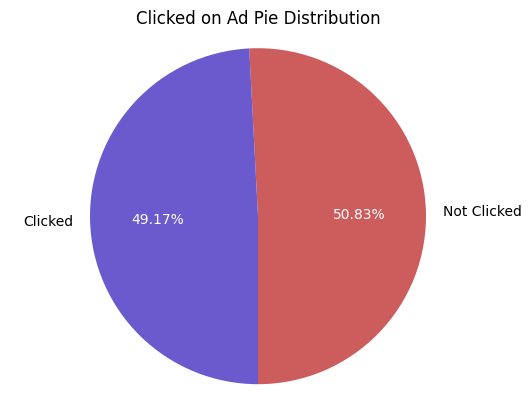

In [ ]:
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    ads,
    labels=["Not Clicked", "Clicked"],
    colors=['IndianRed', "SlateBlue"],
    autopct='%1.1f%%',
    startangle=270
)

for text in autotexts:
    text.set_color('white')
    text.set_fontsize(10)

ax.axis('equal')

plt.title('Clicked on Ad Pie Distribution')
plt.show()

### **Time Spent on Site**

In [ ]:
create_hist(df, "Daily Time Spent on Site", "Clicked on Ad", "Click Through Rate based on Time Spent on Site", {1: 'SlateBlue', 0: 'IndianRed'})

On average, more people have clicked on ad the higher they have spent on site

### **Daily Internet Usage**

In [ ]:
create_hist(df, "Daily Internet Usage", "Clicked on Ad", "Click Through Rate based on Daily Internet Usage", {1: 'SlateBlue', 0: 'IndianRed'})

People who have less daily ineternet usage has a higher likeliness to click through an ad

### **User Age**

In [ ]:
create_hist(df, "Age", "Clicked on Ad", "Click Through Rate based on Age", {1: 'SlateBlue', 0: 'IndianRed'})


Older people tend to click through the ads

### Area Income

In [ ]:
create_box_plot(df, "Area Income", "Clicked on Ad", "Click Through Rate based on Area Income", {1: 'blue', 0: 'red'})


Less income demographics also tend to interact with the ads

### Country

In [ ]:
df1 = df.copy()

country_count = df1.groupby(['Country', 'Continent'])['Clicked on Ad'].value_counts().unstack(fill_value=0)

country_count.columns = ['count_0', 'count_1']

country_count = country_count.reset_index()

country_count.sort_values(by='count_1', ascending=False, inplace=True)


##Limit head to 20 to visualize the graph
fig = px.bar(country_count.head(20), x='Country', y=['count_0', 'count_1'], text_auto=True, color_discrete_map={'count_0': 'IndianRed', 'count_1': 'SlateBlue'})
fig.update_traces(marker_line_width=1,marker_line_color="white")

fig.show()
country_count


,Country,Continent,count_0,count_1
9,Australia,Oceania,63,283
44,Czech Republic,Continental shelf,53,272
187,Turkey,Europe,26,270
14,Bangladesh,Asia,7,177
118,Micronesia,Oceania,7,152
...,...,...,...,...
177,Syrian Arab Republic,Continental shelf,2,0
174,Svalbard & Jan Mayen Islands,Continental shelf,6,0
171,Spain,Europe,44,0
67,Gibraltar,Continental shelf,16,0


In [ ]:
df2 = df.copy()

# Group by 'Country' and count occurrences of 0s and 1s of Clicked on Ad
country = df2.groupby(['Country', 'Continent', 'Clicked on Ad']).size().unstack(fill_value=0)

country['Total'] = country.sum(axis=1)

country.columns = ['Not Clicked', 'Clicked', 'Total']
country = country.reset_index()

country['Percent Clicked'] = (country['Clicked'] / country['Total'] * 100).round(2)
country['Percent NotClicked'] = (country['Not Clicked'] / country['Total'] * 100).round(2)

country.sort_values(by='Clicked', ascending=False, inplace=True)

fig = px.bar(country.head(20), x='Country', y='Clicked', text='Percent Clicked')
fig.update_traces(marker_line_width=1,marker_line_color="white", marker_color="SlateBlue")

fig.show()
country.head(20)

,Country,Continent,Not Clicked,Clicked,Total,Percent Clicked,Percent NotClicked
9,Australia,Oceania,63,283,346,81.79,18.21
44,Czech Republic,Continental shelf,53,272,325,83.69,16.31
187,Turkey,Europe,26,270,296,91.22,8.78
14,Bangladesh,Asia,7,177,184,96.20,3.80
118,Micronesia,Oceania,7,152,159,95.60,4.40
191,Uganda,Africa,7,126,133,94.74,5.26
203,Western Sahara,Continental shelf,5,125,130,96.15,3.85
136,Northern Mariana Islands,Continental shelf,6,116,122,95.08,4.92
128,Netherlands,Europe,4,115,119,96.64,3.36
49,El Salvador,North America,11,106,117,90.60,9.40


In [ ]:
continent = country.groupby('Continent')[['Clicked', 'Not Clicked']].sum()
continent['Total'] = continent.sum(axis=1)

continent['Percent Clicked'] = (continent['Clicked'] / continent['Total'] * 100).round(2)
continent['Percent NotClicked'] = (continent['Not Clicked'] / continent['Total'] * 100).round(2)

continent.sort_values(by='Percent Clicked', ascending=False, inplace=True)

continent

,Clicked,Not Clicked,Total,Percent Clicked,Percent NotClicked
Continent,,,,,
Oceania,627,257,884,70.93,29.07
North America,465,219,684,67.98,32.02
Europe,1343,1048,2391,56.17,43.83
Continental shelf,976,882,1858,52.53,47.47
Asia,598,993,1591,37.59,62.41
South America,127,237,364,34.89,65.11
Africa,645,1368,2013,32.04,67.96


<Axes: xlabel='Continent'>

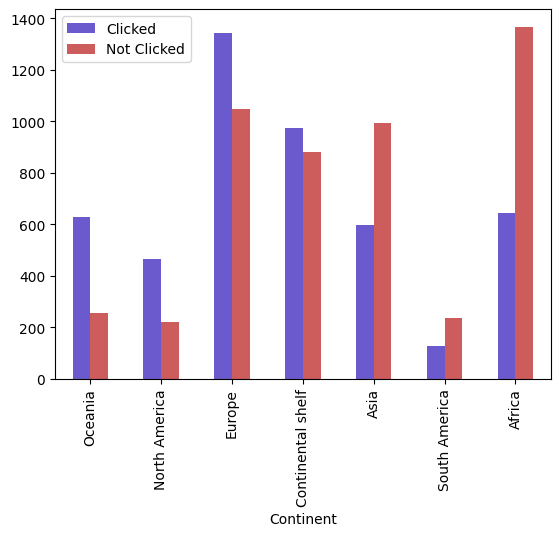

In [ ]:
cplot = continent[['Clicked', 'Not Clicked']]
cplot.plot(kind = 'bar', color=['SlateBlue', 'IndianRed'])

### Timestamp

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Day Category'] = df['Timestamp'].apply(categorize_day)
df['Day Category']

0       Weekday
1       Weekend
2       Weekday
3       Weekday
4       Weekday
         ...   
9995    Weekend
9996    Weekend
9997    Weekday
9998    Weekday
9999    Weekend
Name: Day Category, Length: 10000, dtype: object

In [ ]:
day_cat = df.groupby(['Day Category', 'Clicked on Ad']).size().unstack(fill_value=0)
day_cat.columns = ['Not_Clicked', 'Clicked']

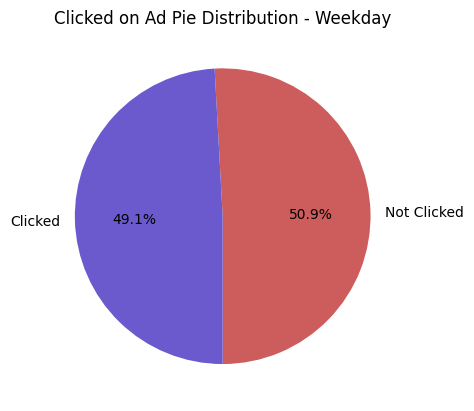

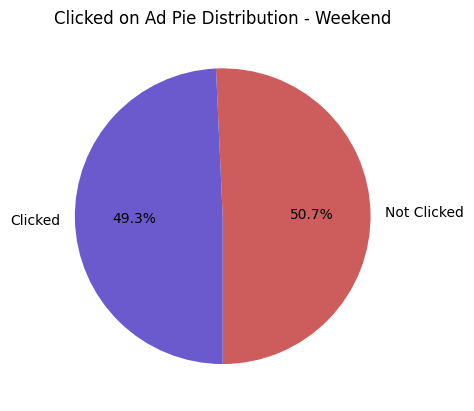

In [ ]:
for index, row in day_cat.iterrows():
    data = [row['Not_Clicked'], row['Clicked']]
    fig, ax = plt.subplots()
    plt.title('Clicked on Ad Pie Distribution - '+index)
    wedges, texts, autotexts = ax.pie(data, labels=['Not Clicked', 'Clicked'], autopct='%1.1f%%', startangle=270, colors=['IndianRed', "SlateBlue"],)


# MODELLING

## Label Encoding

We remove Clicked on ad and Timestamp from the features on X. and Predict clicked on ad on Y

In [ ]:
text_data_features = [i for i in list(df.columns) if i not in list(df.describe().columns)]

df = label_encode(df)
df


Ad Topic Line  :  [ 96 301 484  24 157 300 363  82 182 101 482  52 224 164 230 222 530 470
  59 426 489 143  85 344  19 459  40  32 242 302 180 367 281 350  48  47
  93 332 421 548 450 295 411  35 171   5 541  45  20 152 265  65 437  70
 153 122  33 322 119  60 462 241  54 275 226 342  38 335 488 327 212 525
   7 268 546 249 175 422  76 513 388 343 447 328 349  15 468 481 161 256
  80  17 190 168 219 397  56 496 260 508 360 471  98 545 553 264 352 511
 147 449 220 151 334 532 311 529 167   1 133 233  79 368 140 319 331 390
 134 292 531 556 266 483 248 408 510 307 149 106 199 554 467  90 323 423
 355 410 304 227  91 127 418  21 192 537 318 321 438 441 144 201 517  25
 221  83  64 506 535 497 110  44 501 463 169 165 419 298 396 170 420 413
 326 475 472 109  74 524 115 509 440 278 145 398 215 274  73 309  29 324
 385 102  36 403 372 218 391 253 429 290 433 128  97 178  11 543 207 177
  22 184 495  53 214 474 540  34 469 263 130 234 158 186  37 139 254 528
 202 407  84 273 348 376 188 359 

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad,Continent,Day Category
0,62.26,32.0,69481.85,172.83,96,234,1,174,2016-06-09 21:43:05,0,2,0
1,41.73,31.0,61840.26,207.17,301,460,1,166,2016-01-16 17:56:05,0,1,1
2,44.40,30.0,57877.15,172.83,484,379,0,71,2016-06-29 10:50:45,0,2,0
3,59.88,28.0,56180.93,207.17,24,269,0,205,2016-06-21 14:32:32,0,0,0
4,49.21,30.0,54324.73,201.58,484,495,0,149,2016-07-21 10:54:35,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9994,41.73,28.0,39799.73,217.37,398,58,0,205,2016-03-20 02:44:13,0,0,1
9995,41.73,31.0,61840.26,207.17,353,460,1,166,2016-01-03 03:22:15,1,1,1
9996,41.73,28.0,51501.38,120.49,241,177,1,105,2016-05-28 12:20:15,0,3,1
9997,55.60,39.0,38067.08,124.44,222,316,0,48,2016-01-05 11:53:17,0,0,0


## Feature Selection

In [ ]:
X = df.drop(['Clicked on Ad', 'Timestamp', 'City', 'Ad Topic Line', 'Country'], axis=1)
y = df['Clicked on Ad']

NameError: name 'df' is not defined

## Data Splitting

Test and train split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                           test_size=0.2,
                                           random_state=42)

## Data Training

### XGBoost

Train data using XGBoost

In [ ]:
clf = XGBClassifier(
    random_state = 1000
)

clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=1000, ...)

In [ ]:
# XGBoost prediction
xgb_pred = clf.predict(X_test)

In [ ]:
pd.DataFrame(metrics.classification_report(y_test, xgb_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.811843,0.807692,0.809913,0.809768,0.809866
recall,0.829268,0.788627,0.809913,0.808947,0.809913
f1-score,0.820463,0.798046,0.809913,0.809254,0.809787
support,1025.000000,932.000000,0.809913,1957.000000,1957.000000


Blue area means correct prediction, white means not correct

0 - Not clicked ad

1 - clicked ad

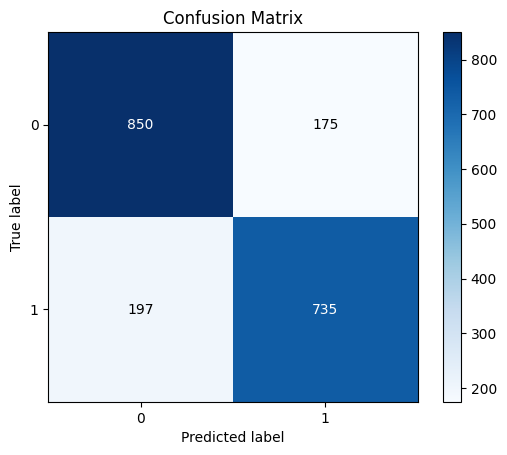

In [ ]:
skplt.metrics.plot_confusion_matrix(y_test, xgb_pred);

In [ ]:
ctr_xgb = dx.Explainer(clf, X_train, y_train, label = "XGBoost Interpretation")

Preparation of a new explainer is initiated

  -> data              : 7828 rows 7 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 7828 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : XGBoost Interpretation
  -> predict function  : <function yhat_proba_default at 0x7e754111a8c0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000312, mean = 0.492, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.938, mean = -8.47e-06, max = 0.967
  -> model_info        : package xgboost

A new explainer has been created!


### Logistic Regression

In [ ]:
ctr_lr = LogisticRegression()

In [ ]:
ctr_lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
lr_pred = ctr_lr.predict(X_test)

pd.DataFrame(metrics.classification_report(y_test, lr_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.697761,0.687006,0.692897,0.692383,0.692639
recall,0.729756,0.652361,0.692897,0.691058,0.692897
f1-score,0.713400,0.669235,0.692897,0.691318,0.692367
support,1025.000000,932.000000,0.692897,1957.000000,1957.000000


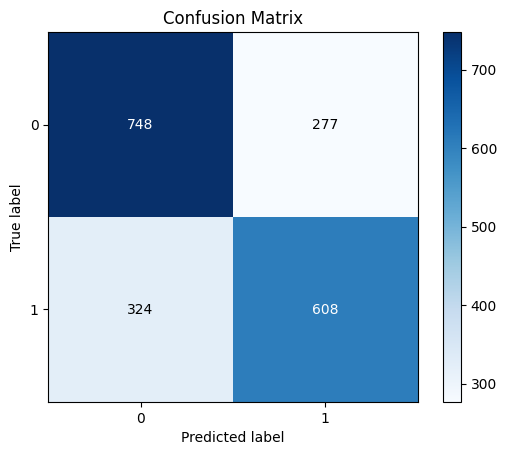

### LightGBM

In [ ]:
ctr_lgbm = LGBMClassifier(random_state = 1000)
ctr_lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3849, number of negative: 3979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 752
[LightGBM] [Info] Number of data points in the train set: 7828, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.491696 -> initscore=-0.033217
[LightGBM] [Info] Start training from score -0.033217


LGBMClassifier(random_state=1000)

In [ ]:
lgbm_pred = ctr_lgbm.predict(X_test)

pd.DataFrame(metrics.classification_report(y_test, lgbm_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.813953,0.829932,0.821155,0.821943,0.821563
recall,0.853659,0.785408,0.821155,0.819533,0.821155
f1-score,0.833333,0.807056,0.821155,0.820195,0.820819
support,1025.000000,932.000000,0.821155,1957.000000,1957.000000


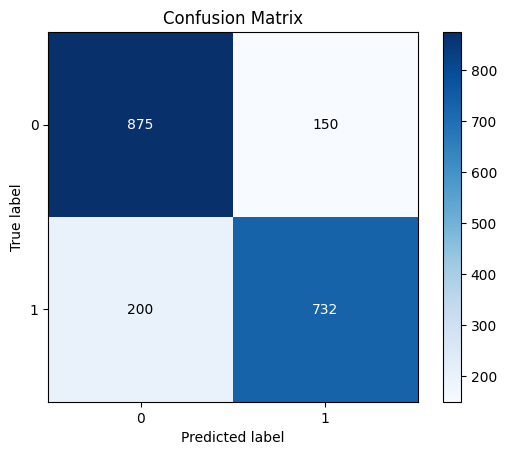

In [ ]:
skplt.metrics.plot_confusion_matrix(y_test, lgbm_pred);

### Random Forest

In [ ]:
ctr_rf = RandomForestClassifier(random_state=42)
ctr_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = ctr_rf.predict(X_test)

pd.DataFrame(metrics.classification_report(y_test, rf_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.796992,0.801792,0.799182,0.799392,0.799278
recall,0.827317,0.768240,0.799182,0.797779,0.799182
f1-score,0.811872,0.784658,0.799182,0.798265,0.798911
support,1025.000000,932.000000,0.799182,1957.000000,1957.000000


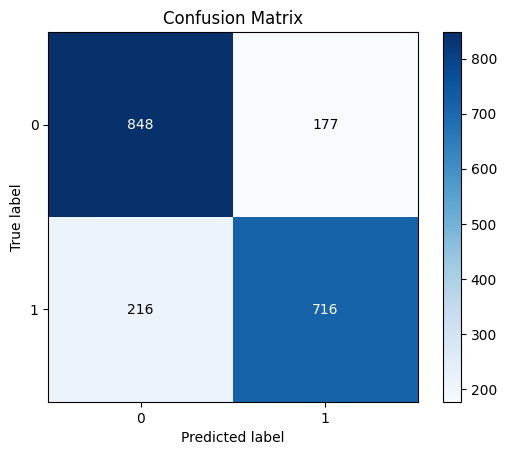

In [ ]:
skplt.metrics.plot_confusion_matrix(y_test, rf_pred);

### Decision Trees

In [ ]:
ctr_dt = DecisionTreeClassifier()
ctr_dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
dt_pred = ctr_dt.predict(X_test)

pd.DataFrame(metrics.classification_report(y_test, dt_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.756522,0.737527,0.747573,0.747024,0.747476
recall,0.763902,0.729614,0.747573,0.746758,0.747573
f1-score,0.760194,0.733549,0.747573,0.746872,0.747505
support,1025.000000,932.000000,0.747573,1957.000000,1957.000000


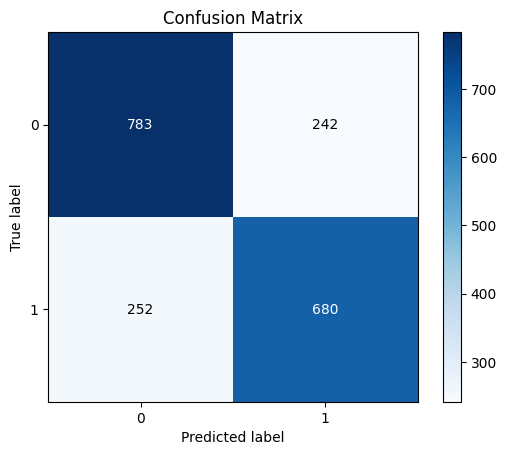

In [ ]:
skplt.metrics.plot_confusion_matrix(y_test, dt_pred);

## Hyperparameter Tuning

We will be using LGBM for hyperparameter tuning as it had a higher accuracy for f1 and recall when predicting ad click rate.

Provided in this link is a comprehensive guide for LGBM hypertuning: https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html#for-better-accuracy



In [ ]:
parameters = {
    'n_estimators': (25,50,75,100),
    'max_depth':(5,10,15,20),
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'num_leaves': [25, 50, 75,100],
    'max_bin': [255, 512, 768, 1024],
    #'num_iterations': [25, 50, 75, 100]
}

lgbm_clf_gridcv = GridSearchCV(ctr_lgbm, parameters, cv=5, scoring='f1')
lgbm_clf_gridcv.fit(X_train, y_train)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

GridSearchCV(cv=5, estimator=LGBMClassifier(random_state=1000),
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.3],
                         'max_bin': [255, 512, 768, 1024],
                         'max_depth': (5, 10, 15, 20),
                         'n_estimators': (25, 50, 75, 100),
                         'num_leaves': [25, 50, 75, 100]},
             scoring='f1')

In [ ]:
cv_result = pd.DataFrame(lgbm_clf_gridcv.cv_results_)
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result[retain_cols].sort_values('rank_test_score')

,params,mean_test_score,rank_test_score
972,"{'learning_rate': 0.3, 'max_bin': 1024, 'max_d...",0.812706,1
844,"{'learning_rate': 0.3, 'max_bin': 512, 'max_de...",0.812706,1
908,"{'learning_rate': 0.3, 'max_bin': 768, 'max_de...",0.812706,1
975,"{'learning_rate': 0.3, 'max_bin': 1024, 'max_d...",0.812620,4
974,"{'learning_rate': 0.3, 'max_bin': 1024, 'max_d...",0.812620,4
...,...,...,...
131,"{'learning_rate': 0.01, 'max_bin': 768, 'max_d...",0.714853,1012
0,"{'learning_rate': 0.01, 'max_bin': 255, 'max_d...",0.713801,1021
3,"{'learning_rate': 0.01, 'max_bin': 255, 'max_d...",0.713722,1022
2,"{'learning_rate': 0.01, 'max_bin': 255, 'max_d...",0.713722,1022


In [ ]:
lgbm_clf_gridcv.best_params_, lgbm_clf_gridcv.best_score_

({'learning_rate': 0.3,
  'max_bin': 512,
  'max_depth': 5,
  'n_estimators': 100,
  'num_leaves': 25},
 0.8127061647436333)

In [ ]:
ctr_lgbm2 = LGBMClassifier(learning_rate= 0.3, max_bin=512, max_depth=5, n_estimators=100, num_leaves=25)
ctr_lgbm2.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3849, number of negative: 3979
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1074
[LightGBM] [Info] Number of data points in the train set: 7828, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.491696 -> initscore=-0.033217
[LightGBM] [Info] Start training from score -0.033217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

LGBMClassifier(learning_rate=0.3, max_bin=512, max_depth=5, num_leaves=25)

In [ ]:
lgbm_pred2 = ctr_lgbm2.predict(X_test)

pd.DataFrame(metrics.classification_report(y_test, lgbm_pred2, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.814151,0.819398,0.816556,0.816774,0.816650
recall,0.841951,0.788627,0.816556,0.815289,0.816556
f1-score,0.827818,0.803718,0.816556,0.815768,0.816340
support,1025.000000,932.000000,0.816556,1957.000000,1957.000000


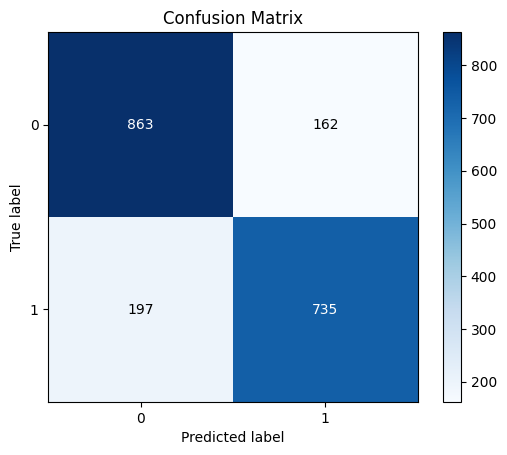

In [ ]:
skplt.metrics.plot_confusion_matrix(y_test, lgbm_pred2);

# EVALUATION

In [ ]:
vri_lgbm = dx.Explainer(ctr_lgbm2, X_train, y_train, label = "LGBM Interpretation")

Preparation of a new explainer is initiated

  -> data              : 7828 rows 7 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 7828 values
  -> model_class       : lightgbm.sklearn.LGBMClassifier (default)
  -> label             : LGBM Interpretation
  -> predict function  : <function yhat_proba_default at 0x7e754111a8c0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000332, mean = 0.492, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.973, mean = -1.88e-05, max = 0.958
  -> model_info        : package lightgbm

A new explainer has been created!


In [ ]:
vri_lgbm.model_parts().plot()

/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:448: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



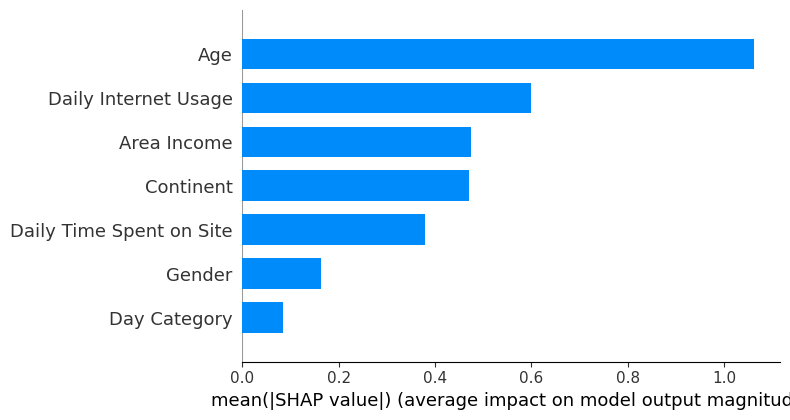

In [ ]:
lgbm_shap_values = shap.TreeExplainer(ctr_lgbm2).shap_values(X_train[:1000])

shap.summary_plot(lgbm_shap_values, X_train[1000:2000], plot_type='bar')

Out of the different models we have used, LightGBM has the best performance. With having shown reliable f1 score of 80% and a recall score of 78%. Which has a high likeliness of being able to predict an ad click based on the features available.

As it also implies in the graphs, Age is the most significant and important feature in determining the user behavior if they will click ad or not. These are then followed by Internet Usage, and Area Income respectively.

# CONCLUSION & RECOMMENDATION

The data shown in this research gives importance to factors that may influence a user's decision to click through an ad. The most important factor shown has been Age, Daily Internet Usage, Area Income, and Continent.

While there may be an underlying reason as to why Continent influences their decision. Age may factor in the user's particular knowledge and interest on a specific marketing, aside from the desired topic the marketing / advertisement wants to endorse.

Organizations can use the discovery on this research to make a data-driven decision and factor in these important features that can help in their marketing campaign. A solid suggestion would be factoring a different set of ads aimed at different country / city for a more personal touch to the campaign rather than making a generalized ad. Since a lot of the people who clicked on the Ad were of higher age, it is important to make it accessible and understandable for them to be engaged with the campaign.